In [7]:
# importar librerias para manejo de sql, dataframe y gráficos
from sqlalchemy import create_engine
from sqlalchemy import text
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Cargar las credenciales desde el archivo py con datos de base de datos local
import configPost1

# Extraer las credenciales
host = configPost1.host
database = configPost1.database
user = configPost1.user
password = configPost1.password
port=configPost1.port

# Crear la conexión
engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{database}')

# definimos una consulta que soporte parametros y convierta la QUERY en cadena de forma adecuada
def consulta(QUERY,engine, params=None):
    return pd.read_sql_query(text(QUERY),engine,params=params)



In [8]:
# Definir consulta en SQL compatible con postgresql
try:
    QUERY = """
    SELECT tablename 
    FROM pg_catalog.pg_tables
    WHERE schemaname NOT IN ('pg_catalog','information_schema');
    """
# Ejecutar la consulta y obtener los resultados en un DataFrame
    df = consulta(QUERY, engine)
# Mostrar los primeros resultados
    print("La conexión se ha realizado con éxito.\n")
    print(df)
except Exception as e:
    print("Hubo un error al realizar la conexión:", e)

La conexión se ha realizado con éxito.

    tablename
0     tmodulo
1     entidad
2   municipio
3   tvivienda
4      thogar
5       tsdem
6           m
7  cat_region
8    cat_tloc


In [9]:
# Agrupar  por entidad y agregar con COUNT para obtener el total de registros
QUERY = """
SELECT 
    h.ent AS entidad,
    e.nom_ent AS nombre,
    COUNT(*) num_encuestas
FROM thogar h
INNER JOIN entidad e
    ON e.cve_ent = h.ent
GROUP BY h.ent, e.nom_ent
ORDER BY entidad;
"""
consulta1 = consulta(QUERY, engine)
consulta1.head()

,entidad,nombre,num_encuestas
0,01,AGUASCALIENTES,634
1,02,BAJA CALIFORNIA,633
2,03,BAJA CALIFORNIA SUR,625
3,04,CAMPECHE,631
4,05,COAHUILA DE ZARAGOZA,624


In [10]:
# Agrupar el par ent - mun y agregar con COUNT para obtener la cantidad de encuestas por municipio
# A partir de esta, normalizar el numero de encuestas por cada 100 viviendas
QUERY = """
SELECT 
    h.entidad,
    h.municipio,
    m.tot_viviendas,
    h.num_encuestas,
    100.0*h.num_encuestas/m.tot_viviendas AS encuestas_100
FROM(
    SELECT
        ent AS entidad,
        mun AS municipio,
        COUNT(*) AS num_encuestas
    FROM thogar
    GROUP BY ent,mun)  h
INNER JOIN municipio m
    ON m.ent_mun = (h.entidad||h.municipio)
ORDER BY 5 DESC;
"""
consulta5 = consulta(QUERY, engine)
consulta5.head()

,entidad,municipio,tot_viviendas,num_encuestas,encuestas_100
0,20,503,124.0,18,14.516129
1,20,246,180.0,19,10.555556
2,08,049,841.0,20,2.378121
3,20,231,802.0,19,2.369077
4,19,043,772.0,18,2.331606


In [5]:
#Exportar el dataframe a csv para llevarlos a otras herramientas de visualización
consulta1.to_csv('consulta1.csv', index = False)
consulta5.to_csv('consulta5.csv', index = False)

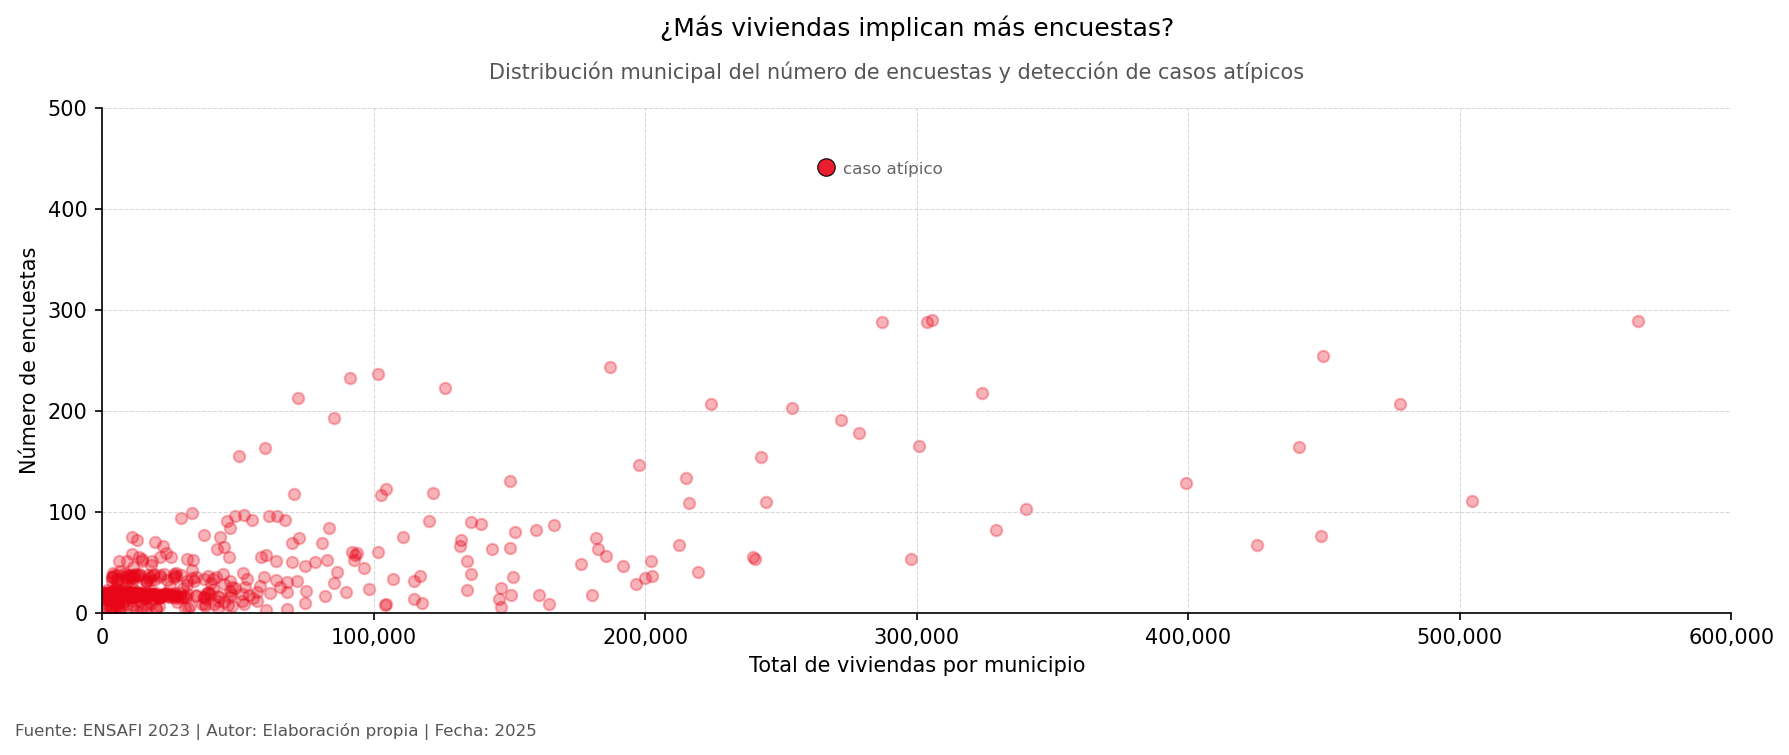

In [11]:
#Separación de valores que parecen atipicos
outlier = consulta5[consulta5['num_encuestas'] > 400]
resto = consulta5[consulta5['num_encuestas'] <= 400]

#lienzo
plt.figure(figsize=(12,5), dpi = 150)

#Gráfico de puntos
plt.scatter(
    resto['tot_viviendas'],
    resto['num_encuestas'],
    color='#E80518',
    s=30,
    alpha=0.3
)

#outlier
plt.scatter(
    outlier['tot_viviendas'],
    outlier['num_encuestas'],
    color='#E80518',
    s=70,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.6
)
plt.figtext(0.47, 0.7, "caso atípico", fontsize=8, color='#646464')

# Etiquetas
plt.xlabel('Total de viviendas por municipio')
plt.ylabel('Número de encuestas')

#Titulo y subtitulo
plt.title('¿Más viviendas implican más encuestas?', pad = 35)
plt.suptitle(
    'Distribución municipal del número de encuestas y detección de casos atípicos',
    fontsize=10,
    y=0.85,
    color='#555555'
)

#Formato
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: format(int(x), ','))
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, p: format(int(y), ','))
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 500)
plt.xlim(0, 600000)

# Fuente y autor
plt.figtext(
    0.01, -0.05,
    "Fuente: ENSAFI 2023 | Autor: Elaboración propia | Fecha: 2025",
    ha="left",
    fontsize=8,
    color="#555555"
)

#Ajuste, carga y descarga de gráfico
plt.tight_layout()
plt.savefig("consulta5a.png", dpi=300, bbox_inches='tight')
plt.show()


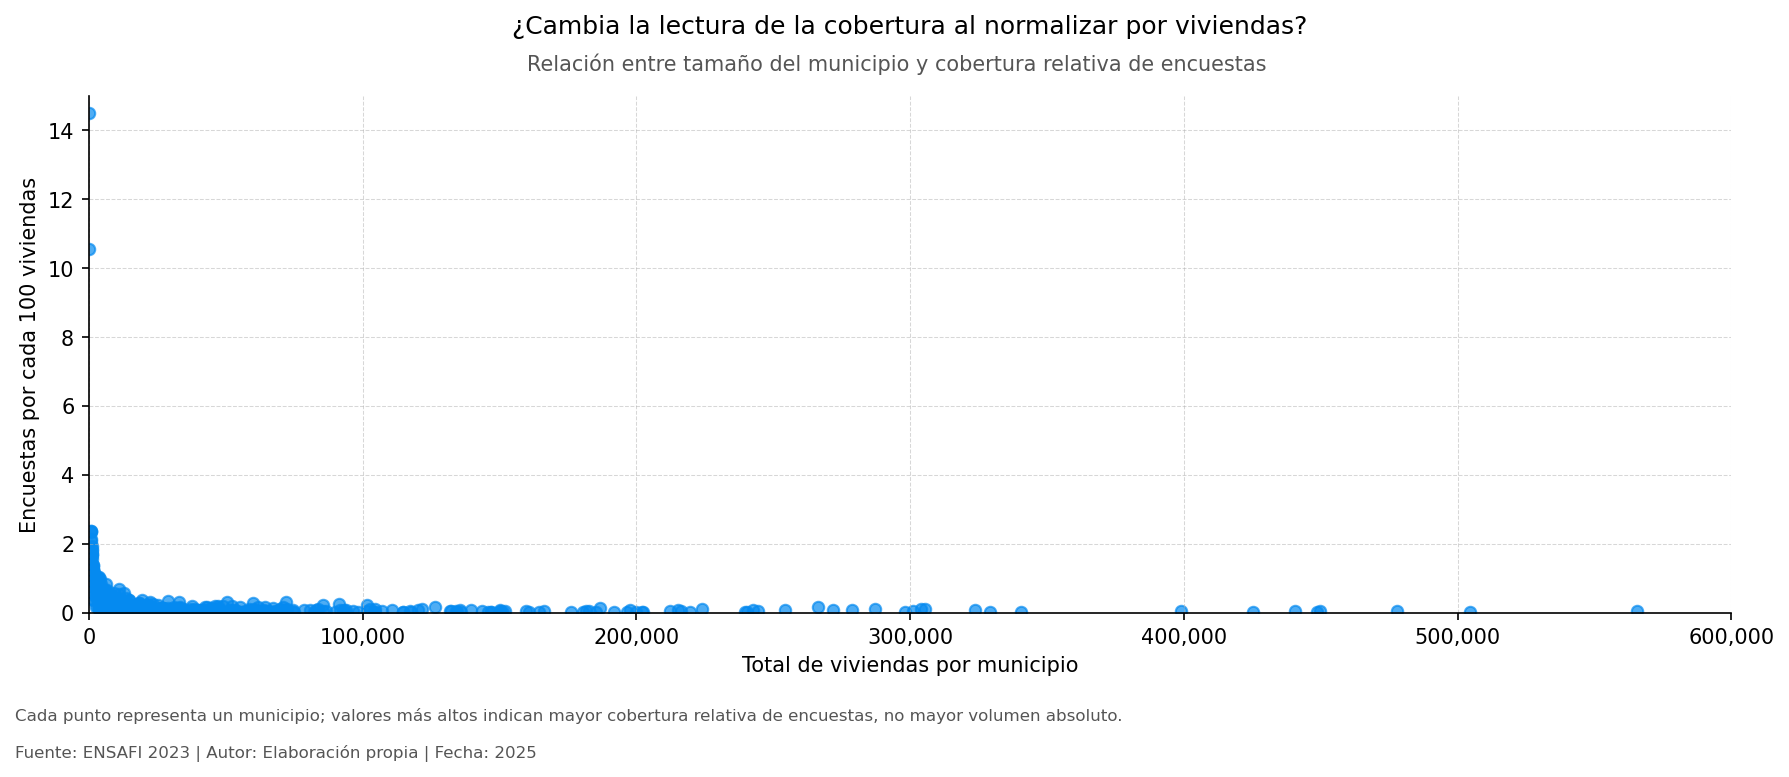

In [12]:
# Lienzo
plt.figure(figsize=(12,5), dpi=150)

# Gráfico de puntos
plt.scatter(
    consulta5['tot_viviendas'],
    consulta5['encuestas_100'],
    color='#058AF0',
    s=30,
    alpha=0.7
)

# Etiquetas
plt.xlabel('Total de viviendas por municipio')
plt.ylabel('Encuestas por cada 100 viviendas')

# Título y subtítulo
plt.title('¿Cambia la lectura de la cobertura al normalizar por viviendas?', pad=30)
plt.suptitle(
    'Relación entre tamaño del municipio y cobertura relativa de encuestas',
    fontsize=10,
    y=0.86,
    color='#555555'
)

# Formato
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.ylim(0, 15)
plt.xlim(0, 600000)

#Guía para leer
plt.figtext(
    0.01, -0.03,
    "Cada punto representa un municipio; valores más altos indican mayor cobertura relativa de encuestas, no mayor volumen absoluto.",
    ha="left",
    fontsize=8,
    color="#555555"
)


# Fuente y autor
plt.figtext(
    0.01, -0.08,
    "Fuente: ENSAFI 2023 | Autor: Elaboración propia | Fecha: 2025",
    ha="left",
    fontsize=8,
    color="#555555"
)

# Ajuste y guardado
plt.tight_layout()
plt.savefig("consulta5b.png", dpi=300, bbox_inches='tight')
plt.show()


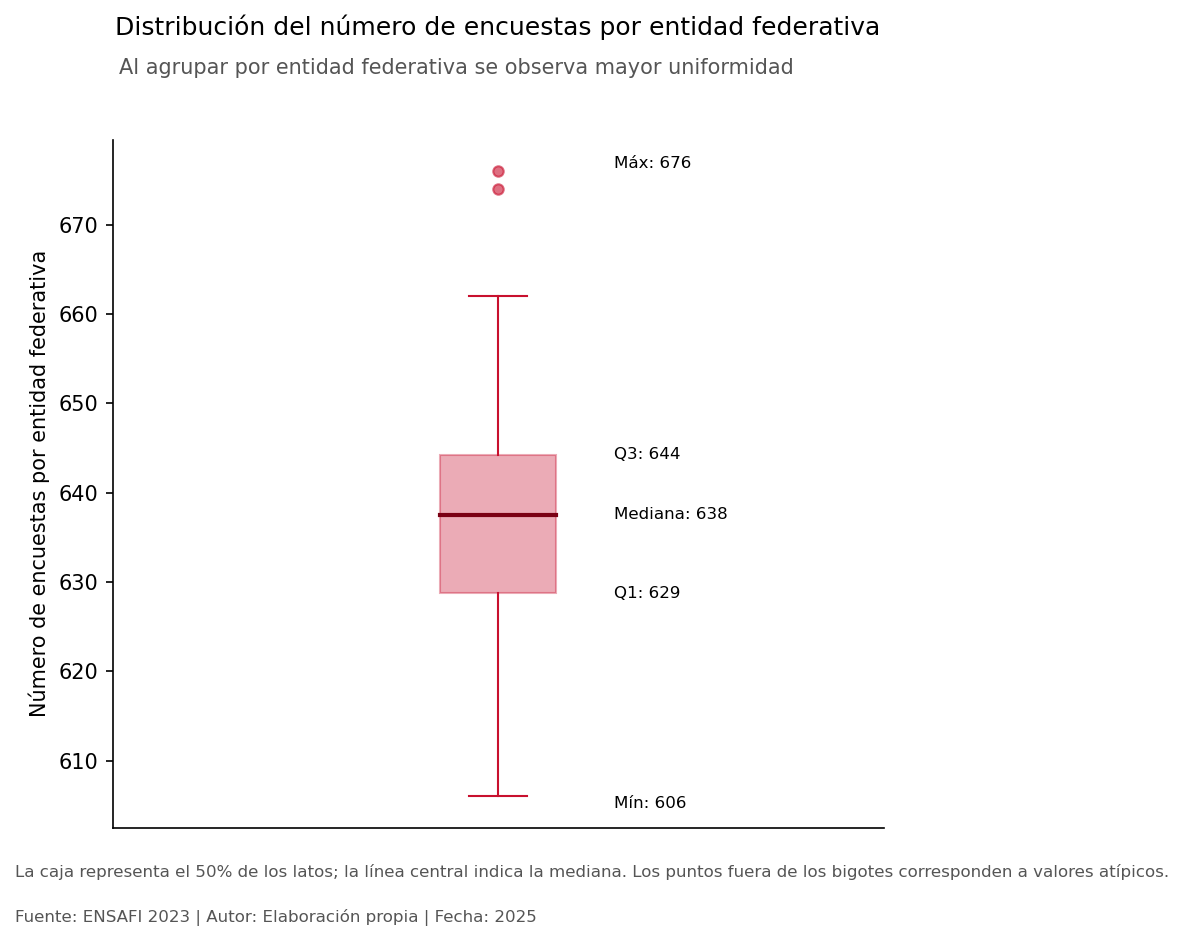

In [13]:
# Estadísticos
stats = consulta1['num_encuestas'].describe()
q1 = stats['25%']
mediana = stats['50%']
q3 = stats['75%']
minimo = stats['min']
maximo = stats['max']

# Lienzo
plt.figure(figsize=(6,6), dpi=150)

# Boxplot
plt.boxplot(
    consulta1['num_encuestas'],
    vert=True,
    patch_artist=True,
    boxprops=dict(
        facecolor='#C8102E',
        alpha=0.35,
        edgecolor='#C8102E',
        linewidth=1
    ),
    medianprops=dict(
        color='#7A0014',
        linewidth=2
    ),
    whiskerprops=dict(
        color='#C8102E',
        linewidth=1
    ),
    capprops=dict(
        color='#C8102E',
        linewidth=1
    ),
    flierprops=dict(
        marker='o',
        markerfacecolor='#C8102E',
        markeredgecolor='#C8102E',
        alpha=0.6,
        markersize=5
    )
)

# Etiquetas
plt.ylabel('Número de encuestas por entidad federativa')


# Título y subtítulo
plt.title('Distribución del número de encuestas por entidad federativa', pad=50)
plt.suptitle('Al agrupar por entidad federativa se observa mayor uniformidad',
    fontsize=10,
    y=0.88,
    color='#555555'
)

# Formato
ax = plt.gca()
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# Anotaciones estadísticas
x_text = 1.15

plt.text(x_text, mediana, f"Mediana: {mediana:.0f}", va='center', fontsize=8)
plt.text(x_text, q3, f"Q3: {q3:.0f}", va='center', fontsize=8)
plt.text(x_text, q1, f"Q1: {q1:.0f}", va='center', fontsize=8)
plt.text(x_text, maximo, f"Máx: {maximo:.0f}", va='bottom', fontsize=8)
plt.text(x_text, minimo, f"Mín: {minimo:.0f}", va='top', fontsize=8)


#Guía para leer
plt.figtext(
    0.01, -0.03,
    "La caja representa el 50% de los latos; la línea central indica la mediana. "
    "Los puntos fuera de los bigotes corresponden a valores atípicos.",
    ha="left",
    fontsize=8,
    color="#555555"
)


# Fuente y autor
plt.figtext(
    0.01, -0.08,
    "Fuente: ENSAFI 2023 | Autor: Elaboración propia | Fecha: 2025",
    ha="left",
    fontsize=8,
    color="#555555"
)

#Ajuste, carga y descarga de gráfico
plt.tight_layout()
plt.savefig("consulta1.png", dpi=300, bbox_inches='tight')
plt.show()


#### Autor: Oscar Gutiérrez Leal
#### Diplomado: Introducción a la Ciencia de Datos
#### Fuente de Datos: Encuesta Nacional sobre Salud Financiera (ENSAFI) 2023. INEGI
#### Fecha de última actualización: Enero 2026
#### Repositorio: https://github.com/ockis2403/ensafi2023
